# Relación entre nitratos/fosfatos y boyas

In [1]:
import pandas as pd
from utils import *
import matplotlib.pyplot as plt
import os

## Nitratos y fosfatos

Cargamos los datos del Canal Mar Menor

El dataset presenta varios problemas: (i) Hay observaciones que tienen dos fechas, como 25-26/05/2022; (ii) Hay observaciones que no tienen fecha; (iii) Hay observaciones que no tienen ningún valor; (iv) Hay strings en los campos que deberían haber números.

In [168]:
# Definir el nombre del archivo y las hojas de interés con sus respectivos rangos de columnas
filename = "Registro_Ramblas_MARMENOR.xlsx"
sheet_info = {
    "Caudal": range(1, 26),
    "Nitratos": range(1, 25),
    "Fosfatos": range(1, 25),
    "Conductividad": range(1, 25),
    "NitratosDiario": range(1, 14),
    "FosfatosDiario": range(1, 14)
}

# Función para cargar y procesar cada hoja
def load_and_process_sheet(sheet_name, usecols):
    # Cargar el dataframe de la hoja con las columnas especificadas
    df = pd.read_excel(filename, sheet_name=sheet_name, skiprows=6, usecols=usecols).dropna(how="all") 
    # Procesar el dataframe: extraer fechas, eliminar NaNs, reemplazar valores
    df['Fecha'] = df['Fecha'].apply(extract_recent_date)
    df = df[~df['Fecha'].isna()]
    df = df.fillna(0)
    df = df.applymap(replace_strings)
    return df

# Cargar y procesar todos los dataframes en un diccionario con nombres como claves
dataframes = {name: load_and_process_sheet(name, cols) for name, cols in sheet_info.items()}


Los puntos que nos interesan a priori son para las boyas CTD7 y 9, que son las más cercanas a las ubicaciones que desembocan al Mar.

Para CTD7: Valla Militar, Venta Simón, Freático los Alcázares, Rambla del Albujón, Aliviadero Estación de Bombeo, Obra de paso bajo carretera Los Urrutia, Desembocadura Rambla de Miranda, Desembocadura Rambla del Miedo.

Para CTD9: Desembocadura Rambla de Matildes, Rambla de las Matildes Corriente Sur, Lo Poyo.

Vemos la cantidad de valores de cada ubicación que no son 0's

In [169]:
(1-(dataframes["Caudal"] == 0).sum()/dataframes["Caudal"].shape[0]).round(2)

Fecha                                      1.00
Total desaguado por rambla Albujón         0.98
Drenaje Los Alcázares                      0.01
Desembocadura rambla Albujón               0.94
Aguas arriba Barrio de la Fuensanta        0.02
Badén aguas abajo La Puebla                0.02
Pasaje la balsa                            0.02
EDAR Torre-Pacheco                         0.00
Tuberías salmuera bajo N-332               0.00
Canal D-7                                  0.95
Azud CHS                                   0.00
Tramo Medio Rambla Albujón                 0.22
Surgencia                                  0.00
Aliviadero                                 0.15
Obra de paso bajo carretera Los Urrutia    0.64
Desembocadura rambla de Miranda            0.21
Desembocadura rambla del Miedo             0.00
El Carmolí                                 0.00
Desembocadura rambla de las Matildes       0.08
Rambla de las Matildes - corriente sur     0.88
Lo Poyo                                 

De acuerdo eso, decidimos quedarnos únicamente con las siguientes ubicaciones para las boyas:
- CTD7: Desembocadura rambla Albujón, Freático los Alcázares (?), Obra de paso bajo carretera Los Urrutia.
- CTD9: Rambla de las Matildes - corriente sur, Lo Poyo.

In [170]:
import matplotlib.pyplot as plt

# Filtrar las columnas en el diccionario de dataframes
cols_to_keep = ["Fecha", "Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia", "Rambla de las Matildes - corriente sur", "Lo Poyo"]

for name, df in dataframes.items():
    # Mantener solo las columnas especificadas que existen en cada dataframe
    existing_cols = df.columns.intersection(cols_to_keep)
    dataframes[name] = df.loc[:, existing_cols]

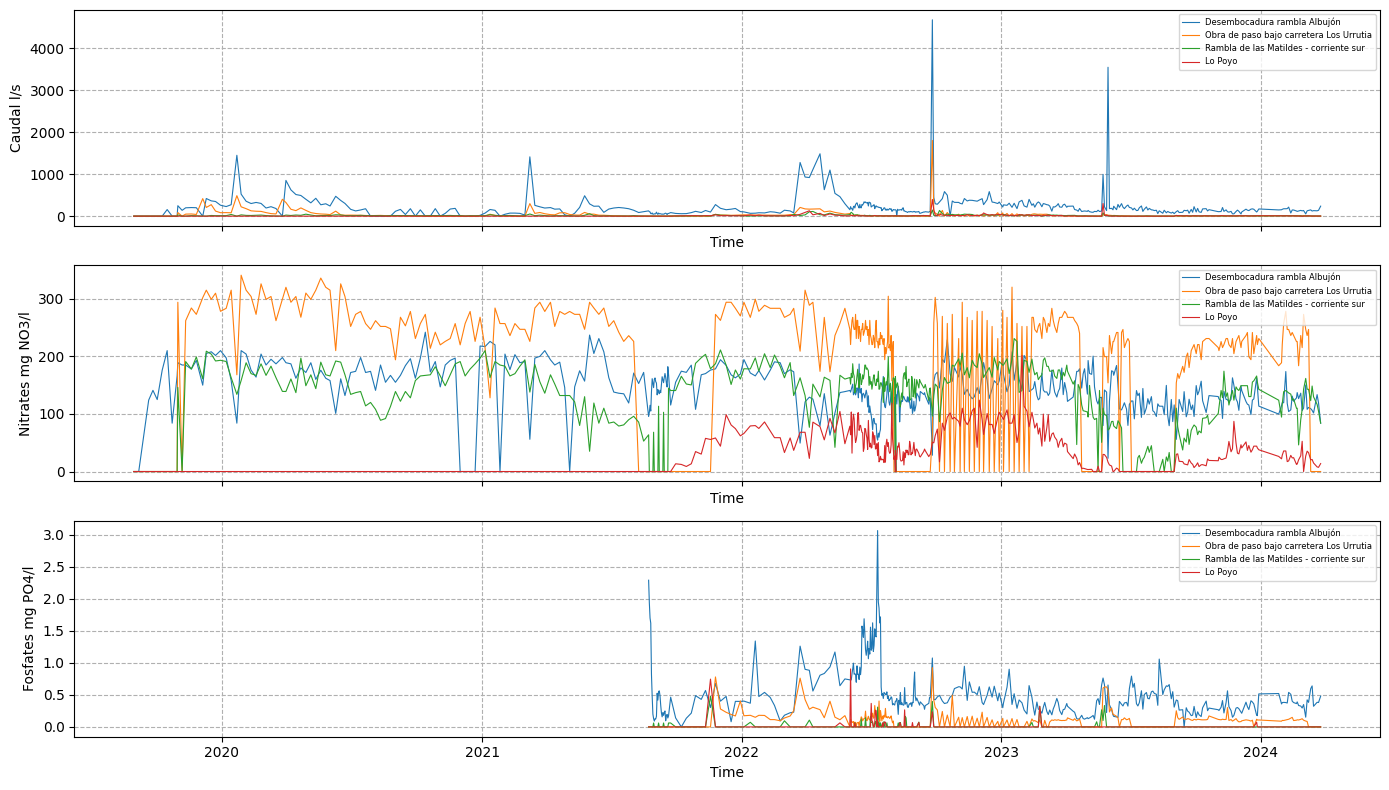

In [171]:

# Crear la figura con subplots
fig, ax = plt.subplots(figsize=(14, 8), nrows=3, ncols=1, sharex=True)

# Plots
# Caudal
for col in dataframes["Caudal"].columns[1:]:
    ax[0].plot(dataframes["Caudal"]["Fecha"], dataframes["Caudal"][col], label=f"{col}", linewidth=0.8)
ax[0].legend(loc="upper right", fontsize=6)
ax[0].set_ylabel("Caudal l/s")
ax[0].set_xlabel("Time")
ax[0].grid(linestyle='--')

# Nitratos
for col in dataframes["Nitratos"].columns[1:]:
    ax[1].plot(dataframes["Nitratos"]["Fecha"], dataframes["Nitratos"][col], label=f"{col}", linewidth=0.8)
ax[1].legend(loc="upper right", fontsize=6)
ax[1].set_ylabel("Nitrates mg NO3/l")
ax[1].set_xlabel("Time")
ax[1].grid(linestyle='--')

# Fosfatos
for col in dataframes["Fosfatos"].columns[1:]:
    ax[2].plot(dataframes["Fosfatos"]["Fecha"], dataframes["Fosfatos"][col], label=f"{col}", linewidth=0.8)
ax[2].legend(loc="upper right", fontsize=6)
ax[2].set_ylabel("Fosfates mg PO4/l")
ax[2].set_xlabel("Time")
ax[2].grid(linestyle='--')


# Ajuste final de la disposición
fig.tight_layout()
plt.show()


In [172]:
from sklearn.ensemble import RandomForestRegressor

In [173]:
# Crear una copia del diccionario de dataframes
dataframes_interpolados = {name: df.copy() for name, df in dataframes.items()}

for name, df in dataframes_interpolados.items():
    # Reemplazar 0 por NaN en todas las columnas excepto 'Fecha'
    dataframes_interpolados[name].loc[:, df.columns != 'Fecha'] = df.loc[:, df.columns != 'Fecha'].replace(0, np.nan)

dataframes_interpolados = {key: df for key, df in dataframes_interpolados.items() if key in ['Caudal', 'Nitratos', 'Fosfatos']}

In [112]:
# Función para rellenar valores nulos en una columna específica usando un modelo de Random Forest
def fill_missing_rf(df, col):
    temp_df = df.copy()
    
    # Seleccionar las filas sin nulos en la columna objetivo para entrenar el modelo
    non_null_data = temp_df.loc[~temp_df.isnull().any(axis=1)]
    
    # Seleccionar filas sin valores nulos en el resto de las columnas (excluyendo 'Fecha')
    #non_null_data = non_null_data.dropna(subset=temp_df.columns.difference([col, 'Fecha']))
    null_data = temp_df.loc[temp_df.isnull().any(axis=1)]

    # Excluir la columna 'Fecha' al entrenar y predecir
    if not null_data.empty and not non_null_data.empty:
        # Crear y entrenar el modelo de Random Forest solo con las columnas numéricas
        rf = RandomForestRegressor(n_estimators=100, random_state=0)
        rf.fit(non_null_data.drop(columns=[col, 'Fecha']), non_null_data[col])

        # Predecir los valores nulos en la columna objetivo
        temp_df.loc[temp_df[col].isnull(), col] = rf.predict(null_data.drop(columns=[col, 'Fecha']))
    
    return temp_df[col]

# Aplicar el modelo de Random Forest en cada columna de cada dataframe, excluyendo 'Fecha'
for name, df in dataframes_interpolados.items():
    for col in df.columns:
        if col != 'Fecha':
            df[col] = fill_missing_rf(df, col)


ValueError: Input X contains NaN.
RandomForestRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Sobre los parámetros de ARIMA:
- p: orden autorregresivo. Número de valores previos de la serie para hacer la predicción
- d: orden de diferenciación. Número de veces que la serie se diferencia para hacerla estacionaria. La diferenciación es Y(t) - Y(t-1)
- q: orden de media móvil. Número de errores pasados que se utilizan para modelar el valor actual de Y(t) 

In [174]:
from statsmodels.tsa.arima.model import ARIMA

# Función para predecir valores nulos usando ARIMA
def fill_missing_arima(df,col):
    #series = series.copy()
    temp_df = df.copy()
    series = temp_df[col]
    # Rellenar valores nulos usando un modelo ARIMA
    is_null = series.isnull()
    if is_null.any():
        model = ARIMA(series.dropna(), order=(7, 0, 7))  # Ajusta los parámetros de ARIMA según tus datos
        # Parametros p, q ,d
        #
        model_fit = model.fit()
        series[is_null] = model_fit.predict(start=is_null.index[0], end=is_null.index[-1])
    return series

# Aplicar el modelo ARIMA en cada columna de cada dataframe
for name, df in dataframes_interpolados.items():
    for col in df.columns:
        if col != 'Fecha':
            df[col] = fill_missing_arima(df, col)


/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parame

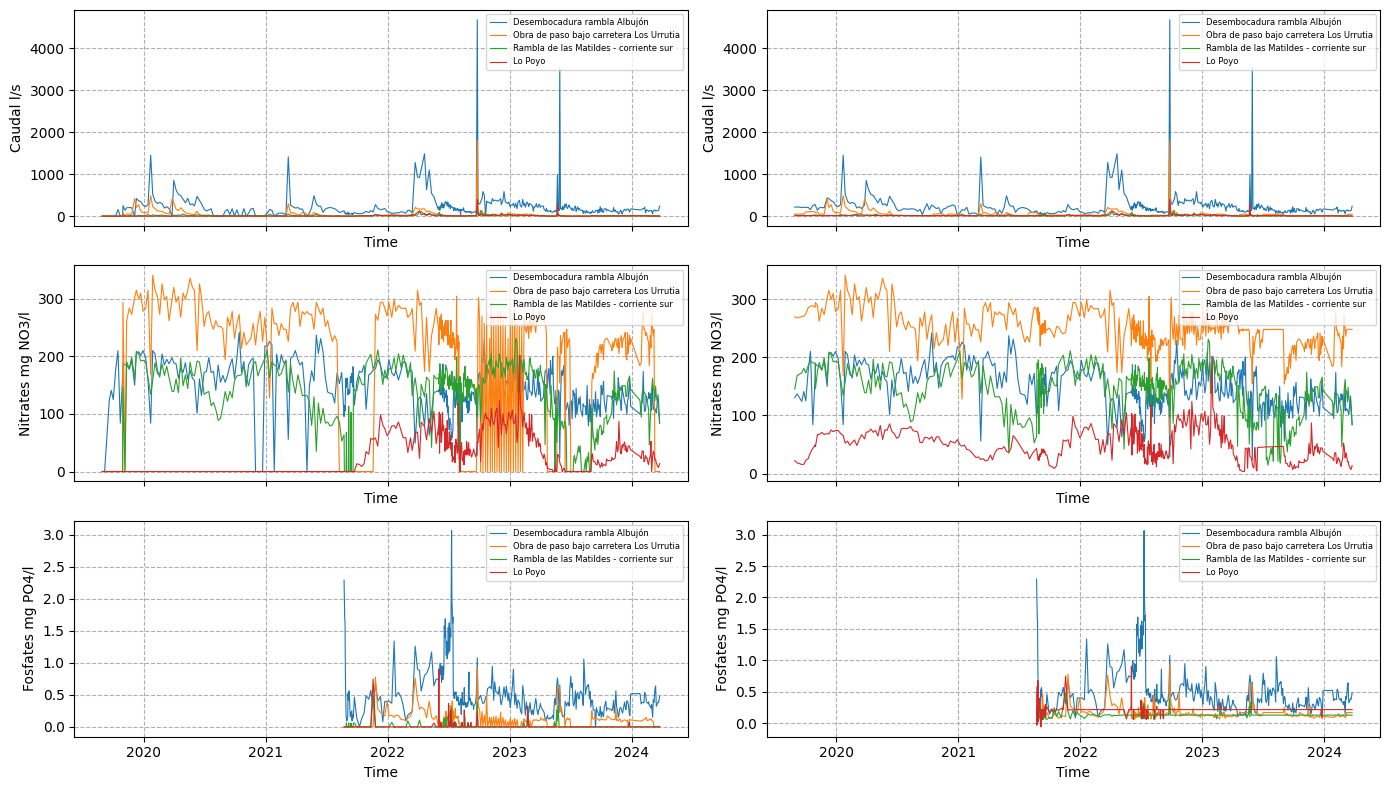

In [156]:

# Crear la figura con subplots
fig, ax = plt.subplots(figsize=(14, 8), nrows=3, ncols=2, sharex=True)

for col in dataframes["Caudal"].columns[1:]:
    ax[0,0].plot(dataframes["Caudal"]["Fecha"], dataframes["Caudal"][col], label=f"{col}", linewidth=0.8)
ax[0,0].legend(loc="upper right", fontsize=6)
ax[0,0].set_ylabel("Caudal l/s")
ax[0,0].set_xlabel("Time")
ax[0,0].grid(linestyle='--')

# Nitratos
for col in dataframes["Nitratos"].columns[1:]:
    ax[1,0].plot(dataframes["Nitratos"]["Fecha"], dataframes["Nitratos"][col], label=f"{col}", linewidth=0.8)
ax[1,0].legend(loc="upper right", fontsize=6)
ax[1,0].set_ylabel("Nitrates mg NO3/l")
ax[1,0].set_xlabel("Time")
ax[1,0].grid(linestyle='--')

# Fosfatos
for col in dataframes["Fosfatos"].columns[1:]:
    ax[2,0].plot(dataframes["Fosfatos"]["Fecha"], dataframes["Fosfatos"][col], label=f"{col}", linewidth=0.8)
ax[2,0].legend(loc="upper right", fontsize=6)
ax[2,0].set_ylabel("Fosfates mg PO4/l")
ax[2,0].set_xlabel("Time")
ax[2,0].grid(linestyle='--')


for col in dataframes_interpolados["Caudal"].columns[1:]:
    ax[0,1].plot(dataframes_interpolados["Caudal"]["Fecha"], dataframes_interpolados["Caudal"][col], label=f"{col}", linewidth=0.8)
ax[0,1].legend(loc="upper right", fontsize=6)
ax[0,1].set_ylabel("Caudal l/s")
ax[0,1].set_xlabel("Time")
ax[0,1].grid(linestyle='--')

# Nitratos
for col in dataframes_interpolados["Nitratos"].columns[1:]:
    ax[1,1].plot(dataframes_interpolados["Nitratos"]["Fecha"], dataframes_interpolados["Nitratos"][col], label=f"{col}", linewidth=0.8)
ax[1,1].legend(loc="upper right", fontsize=6)
ax[1,1].set_ylabel("Nitrates mg NO3/l")
ax[1,1].set_xlabel("Time")
ax[1,1].grid(linestyle='--')

# Fosfatos
for col in dataframes_interpolados["Fosfatos"].columns[1:]:
    ax[2,1].plot(dataframes_interpolados["Fosfatos"]["Fecha"], dataframes_interpolados["Fosfatos"][col], label=f"{col}", linewidth=0.8)
ax[2,1].legend(loc="upper right", fontsize=6)
ax[2,1].set_ylabel("Fosfates mg PO4/l")
ax[2,1].set_xlabel("Time")
ax[2,1].grid(linestyle='--')


# Ajuste final de la disposición
fig.tight_layout()
plt.show()


## Boyas CTD7 y 9

In [161]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = ["CTD7", "CTD9"]#[f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes_boyas = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    
    # Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
    for archivo in archivos_csv:
        if archivo == "Transparency.csv":
            continue
        
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        dataframes_boyas[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)

In [191]:
dataframes_interpolados["Nitratos"]['Nitratos CTD7'] = dataframes_interpolados["Nitratos"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)
dataframes_interpolados["Nitratos"]['Nitratos CTD9'] = dataframes_interpolados["Nitratos"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)
dataframes_interpolados["Fosfatos"]['Fosfatos CTD7'] = dataframes_interpolados["Fosfatos"].loc[:, ["Desembocadura rambla Albujón", "Obra de paso bajo carretera Los Urrutia"]].sum(axis=1)
dataframes_interpolados["Fosfatos"]['Fosfatos CTD9'] = dataframes_interpolados["Fosfatos"].loc[:, ["Rambla de las Matildes - corriente sur", "Lo Poyo"]].sum(axis=1)

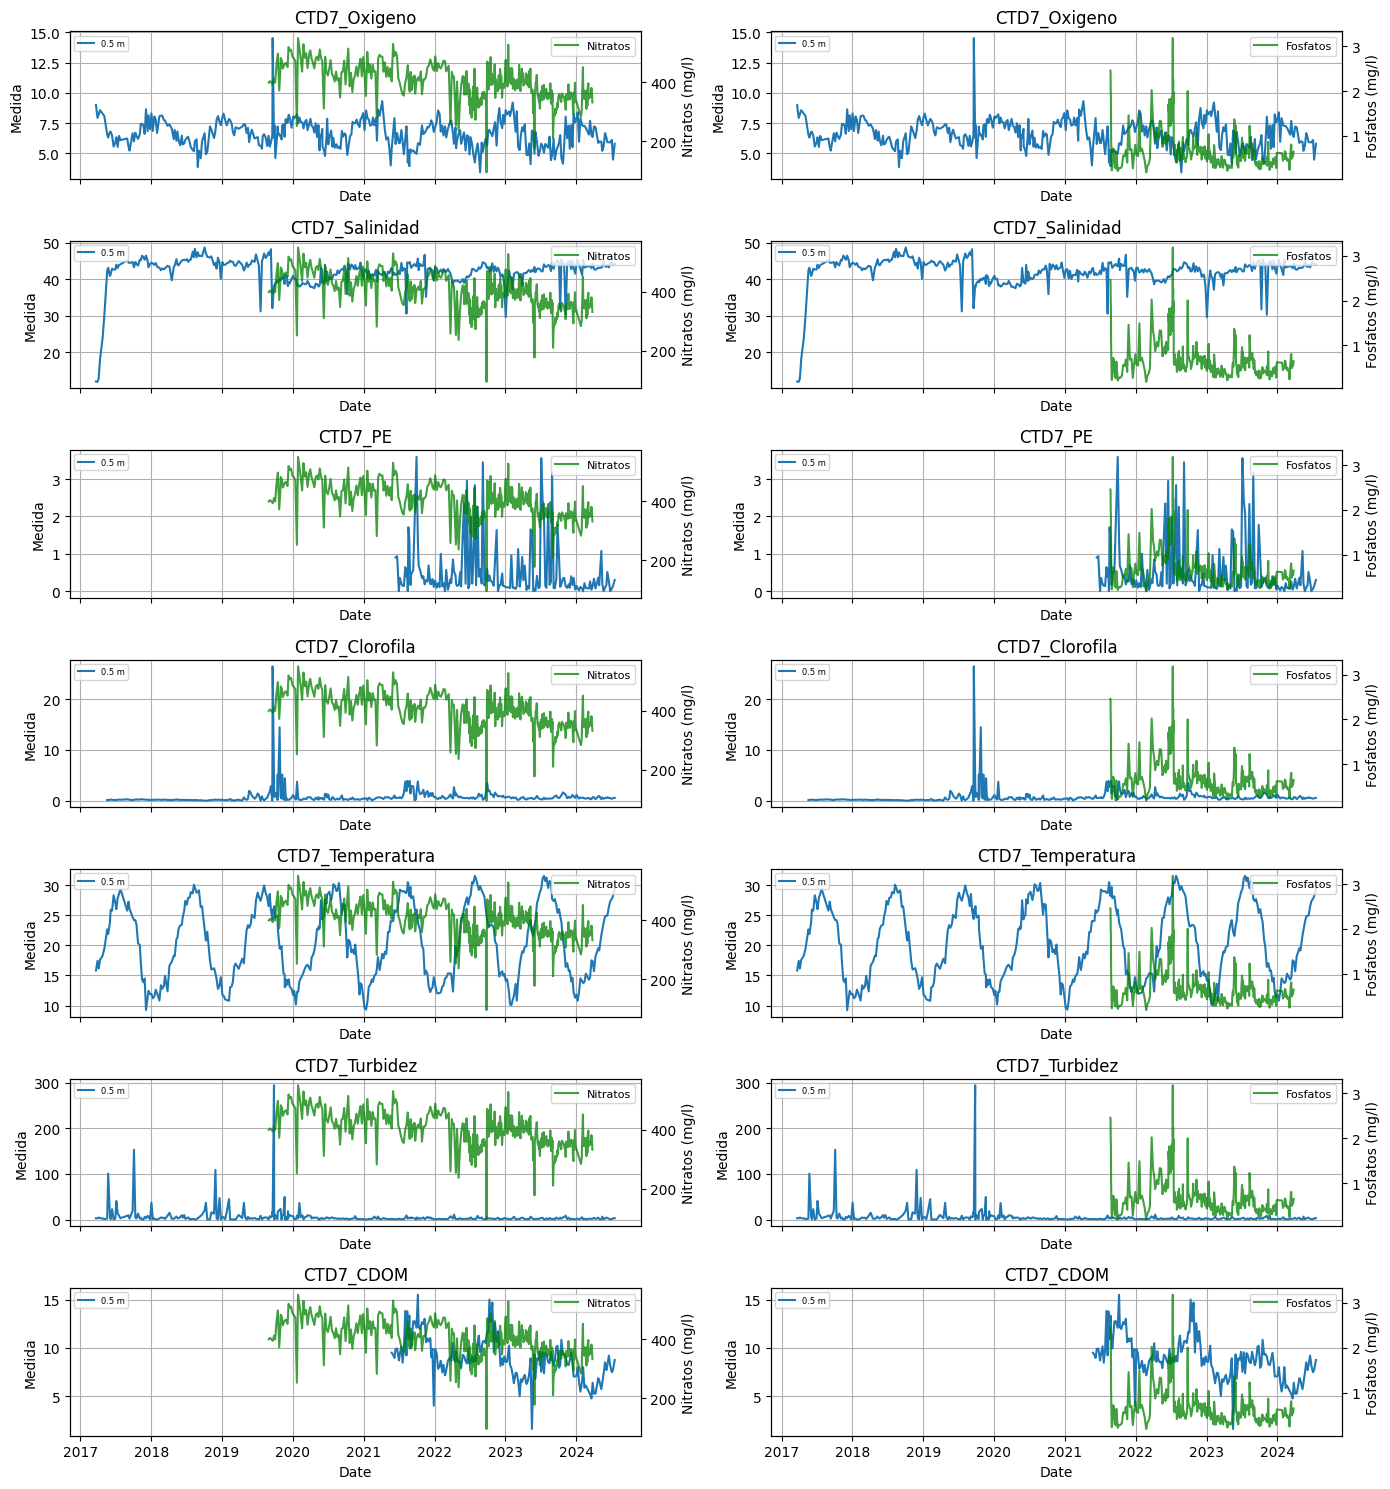

In [196]:
dataframes_CTD7 = {k: v for k, v in dataframes_boyas.items() if "CTD7" in k}

fig, ax = plt.subplots(figsize=(14, 6 * 2.5), nrows=7, ncols=2, sharex=True)

# Iterar sobre cada DataFrame y su correspondiente subplot
for i, (nombre, df) in enumerate(dataframes_CTD7.items()):
    # Convertir la columna 'Date' a datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Graficar la columna de profundidad (ejemplo usando una profundidad específica)
    depths = ["0.5"]
    for depth in depths:
        ax[i,0].plot(df['Date'], df[depth], label=f'{depth} m')

    ax[i,0].set_title(nombre)
    ax[i,0].set_xlabel('Date')
    ax[i,0].set_ylabel('Medida')
    ax[i,0].legend(loc='upper left', fontsize=6)
    ax[i,0].grid(True)

    ax2 = ax[i,0].twinx()
    ax2.plot(dataframes_interpolados["Nitratos"]["Fecha"], dataframes_interpolados["Nitratos"]["Nitratos CTD7"], label="Nitratos", color="green", alpha=0.75)
    #ax2.plot(dataframes_interpolados["Nitratos"]["Fecha"], dataframes_interpolados["Nitratos"]["Obra de paso bajo carretera Los Urrutia"], label="Nitratos", color="orange", alpha=0.75)
    ax2.set_ylabel("Nitratos (mg/l)")
    ax2.legend(loc="upper right", fontsize=8)


    for depth in depths:
        ax[i,1].plot(df['Date'], df[depth], label=f'{depth} m')

    ax[i,1].set_title(nombre)
    ax[i,1].set_xlabel('Date')
    ax[i,1].set_ylabel('Medida')
    ax[i,1].legend(loc='upper left', fontsize=6)
    ax[i,1].grid(True)

    ax2 = ax[i,1].twinx()
    ax2.plot(dataframes_interpolados["Fosfatos"]["Fecha"], dataframes_interpolados["Fosfatos"]["Fosfatos CTD7"], label="Fosfatos", color="green", alpha=0.75)
    #ax2.plot(dataframes_interpolados["Nitratos"]["Fecha"], dataframes_interpolados["Nitratos"]["Obra de paso bajo carretera Los Urrutia"], label="Nitratos", color="orange", alpha=0.75)
    ax2.set_ylabel("Fosfatos (mg/l)")
    ax2.legend(loc="upper right", fontsize=8)


    

fig.tight_layout()